# Ensemble Uncertainty Estimation for Semantic Segmentation

This notebook implements ensemble uncertainty estimation for Mask2Former semantic segmentation using TorchUncertainty.

**Key Features:**
- Sequential model inference for memory efficiency
- TorchUncertainty metrics for uncertainty decomposition
- Per-class IoU and calibration analysis
- Comprehensive uncertainty statistics
- Optional visualization

**Uncertainty Types:**
- **Aleatoric**: Data noise uncertainty
- **Epistemic**: Model disagreement uncertainty  
- **Total**: Combined uncertainty

## 1. Setup and Imports

In [1]:
import os
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings('ignore')
plt.style.use('default')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.8.0
CUDA available: False


In [2]:
# TorchUncertainty imports
try:
    from torch_uncertainty.metrics.diversity import Entropy, MutualInformation, VariationRatio
    from torch_uncertainty.metrics.calibration import CalibrationError
    from torch_uncertainty.metrics.others import AUSE
    print('✅ TorchUncertainty imported successfully')
    TORCH_UNCERTAINTY_AVAILABLE = True
except ImportError as e:
    print(f'❌ TorchUncertainty import failed: {e}')
    print('Falling back to torchmetrics for IoU calculation.')
    TORCH_UNCERTAINTY_AVAILABLE = False
    try:
        from torchmetrics import JaccardIndex
        print('✅ torchmetrics.JaccardIndex imported for IoU.')
    except ImportError as e2:
        print(f'❌ torchmetrics import failed: {e2}')
        print('Please install: pip install torchmetrics')
        sys.exit(1)

❌ TorchUncertainty import failed: No module named 'torch_uncertainty.metrics.diversity'
Falling back to torchmetrics for IoU calculation.
✅ torchmetrics.JaccardIndex imported for IoU.


In [3]:
# Project imports (adjust paths as needed)
SCRIPT_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(SCRIPT_DIR, '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

try:
    from src.models.mask2former import get_mask2former_model, get_preprocessor
    from src.data.coco_dataset import COCODataset, ImageSegmentationDataset
    from src.data.transforms import test_transform, target_transform
    from src.utils.palette import label2id, palette, id2label_remapped, remap_labels
    print('✅ Project modules imported successfully')
except ImportError as e:
    print(f'❌ Project import failed: {e}')
    print('Please ensure your project structure is correct')

✅ Project modules imported successfully


## 2. Configuration

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

CONFIG = {
    'coco_json_path': '/Users/rk/Downloads/Thesis/CKA_sweet_pepper_2020_summer/CKA_sweet_pepper_2020_summer.json',
    'dataset_root_dir': '/Users/rk/Downloads/Thesis/',
    'ensemble_models_dir': 'Output/',
    'output_dir': 'Output/uncertainty_visualizations_notebook',
    'checkpoint_files': [
        'best_model_epoch_27.pt'
    ],
    'batch_size': 3,
    'max_visualize': 10,
    'num_workers': 0
}

if not os.path.exists(CONFIG['coco_json_path']):
    print(f"⚠️  Warning: COCO JSON not found at {CONFIG['coco_json_path']}")
    print('Please update the path in CONFIG above')
else:
    print('✅ COCO dataset path validated')

os.makedirs(CONFIG['output_dir'], exist_ok=True)
print(f"Output directory: {CONFIG['output_dir']}")

num_classes = len(label2id)
print(f'Number of classes: {num_classes}')
print(f'Class mapping: {label2id}')

Using device: cpu
✅ COCO dataset path validated
Output directory: Output/uncertainty_visualizations_notebook
Number of classes: 8
Class mapping: {0: 0, 11: 1, 12: 2, 13: 3, 14: 4, 15: 5, 17: 6, 18: 7}


## 3. Data Loading

In [5]:
print('📁 Loading test dataset...')
base_test_ds = COCODataset(CONFIG['coco_json_path'], CONFIG['dataset_root_dir'], split='test')
test_dataset = ImageSegmentationDataset(base_test_ds, transform=test_transform, target_transform=target_transform, label2id=label2id)
print(f'✅ Test dataset loaded: {len(test_dataset)} samples')

📁 Loading test dataset...
✅ Test dataset loaded: 93 samples
✅ Test dataset loaded: 93 samples


In [6]:
def inference_collate_fn(batch):
    images, masks, orig_images, orig_masks = zip(*batch)
    preprocessor = get_preprocessor(num_classes)
    processed = preprocessor(list(images), segmentation_maps=list(masks), return_tensors='pt')
    return {
        'pixel_values': processed['pixel_values'],
        'original_images': list(orig_images),
        'original_segmentation_maps': list(orig_masks)
    }

test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, collate_fn=inference_collate_fn, num_workers=CONFIG['num_workers'])
print(f'✅ DataLoader created: {len(test_dataloader)} batches')

✅ DataLoader created: 31 batches


🔍 Testing single batch...
Batch shapes:
  - pixel_values: torch.Size([3, 3, 640, 360])
  - original_images: 3
  - original_segmentation_maps: 3
Batch shapes:
  - pixel_values: torch.Size([3, 3, 640, 360])
  - original_images: 3
  - original_segmentation_maps: 3


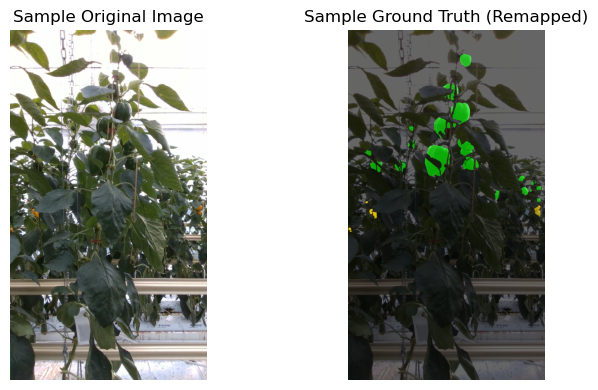

Sample GT shape: torch.Size([1280, 720])
Unique GT labels: [0 3 4 7]


In [8]:
print('🔍 Testing single batch...')
sample_batch = next(iter(test_dataloader))
print(f'Batch shapes:')
print(f'  - pixel_values: {sample_batch["pixel_values"].shape}')
print(f'  - original_images: {len(sample_batch["original_images"])}')
print(f'  - original_segmentation_maps: {len(sample_batch["original_segmentation_maps"])}')
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
orig_img = np.array(sample_batch['original_images'][0])
axes[0].imshow(orig_img)
axes[0].set_title('Sample Original Image')
axes[0].axis('off')
gt_mask = np.array(sample_batch['original_segmentation_maps'][0])
# Remap mask for correct color mapping
remapped_mask = remap_labels(gt_mask, label2id)
custom_cmap = mcolors.ListedColormap(np.array(palette) / 255.0)
axes[1].imshow(orig_img)
axes[1].imshow(remapped_mask, cmap=custom_cmap, alpha=0.6, vmin=0, vmax=len(palette)-1)
axes[1].set_title('Sample Ground Truth (Remapped)')
axes[1].axis('off')
plt.tight_layout()
plt.show()
print(f'Sample GT shape: {remapped_mask.shape}')
print(f'Unique GT labels: {np.unique(remapped_mask)}')